# Exercise 6 — Bayes Classification and Naive Bayes

In this notebook, you will learn:

* what Bayes classification means
* how probabilities can be used for classification
* why Naive Bayes is useful for text
* how to build a simple spam / not spam classifier
* how NLP turns text into numbers

## Part A — Classification with Probabilities

In classification, we want to answer: `Which class is most likely?`

Example:
`Email → spam or not spam`

Bayes classification chooses the class with the highest probability: `choose the class with the highest P(class | data)`


## Part B — Bayes Rule

Bayes rule is: `P(class | data) = P(data | class) × P(class) / P(data)`

For classification, we compare classes.

Since P(data) is the same for all classes, we can compare: `score = P(data | class) × P(class)`
The class with the highest score wins.

## Part C — Intuition

Imagine we receive this message: `"win money now"`

Is this more likely to be spam or not spam?

Naive Bayes checks:

* how common spam is
* how common these words are in spam
* how common these words are in normal messages

## Part D — Tiny Training Dataset

<img src="https://c4.wallpaperflare.com/wallpaper/701/872/935/mr-robot-tv-series-hello-friend-elliot-mr-robot-hd-wallpaper-preview.jpg" width="250">

In [2]:
import pandas as pd

data = [
    {"message": "hello friend", "label": "normal"},
    {"message": "hello book", "label": "normal"},
    {"message": "friend book", "label": "normal"},
    {"message": "hello friend book money", "label": "normal"},
    {"message": "hello friend", "label": "normal"},
    {"message": "book friend", "label": "normal"},

    {"message": "win money", "label": "spam"},
    {"message": "money now", "label": "spam"},
    {"message": "win money now", "label": "spam"},
]

df = pd.DataFrame(data)
df

,message,label
0,hello friend,normal
1,hello book,normal
2,friend book,normal
3,hello friend book money,normal
4,hello friend,normal
5,book friend,normal
6,win money,spam
7,money now,spam
8,win money now,spam


## Part E — Gentle NLP Introduction

Machine learning models cannot read raw text directly.

We need to transform text into numbers.

This process is called: `text vectorization`

A very simple method is: `count the words`

Example: `"hello friend money"`

In [3]:
from sklearn.feature_extraction.text import CountVectorizer

texts = ["hello friend money money!"]

# Create the vectorizer using Scikit-learn
vectorizer = CountVectorizer()

# Transform text into numbers
X = vectorizer.fit_transform(texts)


In [4]:
# Show the words
vectorizer.get_feature_names_out()


array(['friend', 'hello', 'money'], dtype=object)

In [5]:
# Show the numeric vector
X.toarray()

array([[1, 1, 2]])

## Part F — Vocabulary

A vocabulary is the list of words the model knows.

In [8]:
X_counts = vectorizer.fit_transform(df["message"])

vocabulary = vectorizer.get_feature_names_out()

print(vocabulary)

['book' 'friend' 'hello' 'money' 'now' 'win']


## Part G — Word Count Table

In [7]:
X_table = pd.DataFrame(
    X_counts.toarray(),
    columns=vocabulary
)

X_table["label"] = df["label"]

X_table

,book,friend,hello,money,now,win,label
0,0,1,1,0,0,0,normal
1,1,0,1,0,0,0,normal
2,1,1,0,0,0,0,normal
3,1,1,1,1,0,0,normal
4,0,1,1,0,0,0,normal
5,1,1,0,0,0,0,normal
6,0,0,0,1,0,1,spam
7,0,0,0,1,1,0,spam
8,0,0,0,1,1,1,spam


### Questions

1. What does one row represent? One row represents a single message or document contained in the dataset.
2. What does one column represent? One column represents an individual word from the vocabulary (used as an input feature) or the output label (“spam” or “normal”)
3. Why do we need to convert text into numbers? We need to convert text into numbers since machine learning algorithms operate mathematically, they require numerical inputs and cannot directly work with raw text strings when computing weights.
4. Which words seem associated with spam? Words such as “money,” “now,” and “win,” because they appear only in spam messages with counts greater than zero.
5. Which words seem associated with normal messages? Words like “book,” “hello,” and “friend,” since they are found exclusively in normal messages.

## Part H — Priors

The prior probability is how common each class is before seeing the message.

In [9]:
class_counts = df["label"].value_counts()
priors = class_counts / len(df)

priors

label
normal    0.666667
spam      0.333333
Name: count, dtype: float64


* `normal is more common because we have more normal messages`
* `spam is less common because we have fewer spam messages`

### Word Probabilities by Class

Now we count how often each word appears in each class.

In [10]:
word_counts_by_class = X_table.groupby("label")[vocabulary].sum()

word_counts_by_class

,book,friend,hello,money,now,win
label,,,,,,
normal,4,5,4,1,0,0
spam,0,0,0,3,2,2


### Convert Counts to Probabilities

This divides each word count by the total number of words in that class.

In [11]:
word_probs_by_class = word_counts_by_class.div(
    word_counts_by_class.sum(axis=1),
    axis=0
)

word_probs_by_class

,book,friend,hello,money,now,win
label,,,,,,
normal,0.285714,0.357143,0.285714,0.071429,0.000000,0.000000
spam,0.000000,0.000000,0.000000,0.428571,0.285714,0.285714


### Questions

1. Which words have high probability in spam? "Money", "now, and "win".
2. Which words have high probability in normal messages? "Friend", "book" and "hello".
3. What happens if a word never appears in one class? According to the Naive Bayes rule, the conditional probability for that particular class becomes exactly zero.
4. Why might this be a problem? This can be a problem as in the training dataset, if a word never appears in a certain class, the model may assume that the word can never belong to that class in future predictions. However, there is no guarantee that the word will never occur in that class later on, which can lead to incorrect predictions by the model.

## Part J — Classify a New Message Manually

New message: `"hello money"`
We compare:

`score(normal) = P(normal) × P(hello | normal) × P(money | normal)`

`score(spam) = P(spam) × P(hello | spam) × P(money | spam)`


In [12]:
new_message = "money money"

words = new_message.split()

scores = {}

for label in ["normal", "spam"]:
    score = priors[label]

    for word in words:
        score = score * word_probs_by_class.loc[label, word]

    scores[label] = score

scores

{'normal': np.float64(0.0034013605442176865),
 'spam': np.float64(0.06122448979591836)}

### Decision

In [13]:
predicted_class = max(scores, key=scores.get)

print("Predicted class:", predicted_class)

Predicted class: spam


### Part K — Problem: Zero Probabilities

If a word never appears in a class, its probability is zero.

Example: `P(book | spam) = 0`

Then the whole score becomes zero: `P(spam) × P(book | spam) × ...`

This is too harsh.
    

## Part L — Laplace Smoothing

Laplace smoothing fixes zero probabilities by adding 1 to every word count. `smoothed count = count + 1`

This means: `No word gets probability zero`

#### Apply Laplace Smoothing

In [14]:
alpha = 1

smoothed_counts = word_counts_by_class + alpha

smoothed_probs = smoothed_counts.div(
    smoothed_counts.sum(axis=1),
    axis=0
)

smoothed_probs

,book,friend,hello,money,now,win
label,,,,,,
normal,0.250000,0.300000,0.250000,0.100000,0.050000,0.050000
spam,0.076923,0.076923,0.076923,0.307692,0.230769,0.230769


#### Classify Again With Smoothing

In [15]:
new_message = "money money"

words = new_message.split()

scores = {}

for label in ["normal", "spam"]:
    score = priors[label]

    for word in words:
        score = score * smoothed_probs.loc[label, word]

    scores[label] = score

scores

{'normal': np.float64(0.006666666666666667),
 'spam': np.float64(0.03155818540433925)}

In [16]:
predicted_class = max(scores, key=scores.get)

print("Predicted class:", predicted_class)

Predicted class: spam


### Questions

1. Did smoothing change the probabilities? Yes. It slightly adjusts all probability values. Unseen words, which previously had a probability of 0, are assigned a small positive probability, while the probabilities of other words are reduced slightly so that the total probability still sums to 1.
2. Why is smoothing useful? This helps prevent the zero-probability problem. In Naive Bayes, if even one word has a probability of 0, multiplying it with the probabilities of the other words will make the entire joint probability equal to 0. As a result, the model would completely disregard that class.
3. Why should unseen words not make the whole score zero? A message may still contain several other words that strongly indicate its correct class. Therefore, if a word has never appeared before, the model should not automatically treat the entire message as impossible for that class. For example:

score(normal) = P(normal) × P(hello | normal) × P(money | normal)

Even if the word “money” has never appeared in the “normal” class, it should not force the entire score to become 0.

## Part M — Use Scikit-Learn Naive Bayes

Now we use a ready-made Naive Bayes classifier.

In [17]:
from sklearn.naive_bayes import MultinomialNB

X = X_counts
y = df["label"]

model = MultinomialNB()

model.fit(X, y)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


#### Predict New Messages

In [18]:
new_messages = [
    "hello friend",
    "win money now",
    "book money",
    "hello book",
]

X_new = vectorizer.transform(new_messages)

predictions = model.predict(X_new)

for message, pred in zip(new_messages, predictions):
    print(message, "→", pred)

hello friend → normal
win money now → spam
book money → normal
hello book → normal


#### Prediction Probabilities

In [19]:
probabilities = model.predict_proba(X_new)

pd.DataFrame(
    probabilities,
    columns=model.classes_,
    index=new_messages
)

,normal,spam
hello friend,0.962049,0.037951
win money now,0.029610,0.970390
book money,0.678715,0.321285
hello book,0.954802,0.045198


## Part N — Evaluate the Model

Since our tiny dataset is very small, evaluation is limited.

But we can still inspect predictions.

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = model.predict(X)

accuracy = accuracy_score(y, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


#### Confusion Matrix

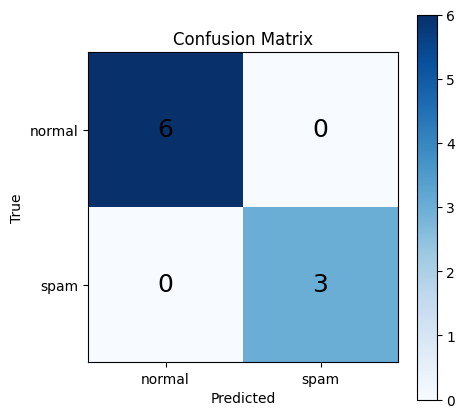

In [21]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred, labels=["normal", "spam"])

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")

plt.xticks([0, 1], ["normal", "spam"])
plt.yticks([0, 1], ["normal", "spam"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=18)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.colorbar()
plt.show()

## Part O — Try a Real SMS Spam Dataset

For a real dataset, use the UCI SMS Spam Collection:

UCI SMS Spam Collection￼ https://archive.ics.uci.edu/dataset/228/sms+spam+collection

A convenient raw version:

In [22]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

sms_df = pd.read_csv(
    url,
    sep="\\t",
    header=None,
    names=["label", "message"]
)

sms_df.head()

C:\Users\hello\AppData\Local\Temp\ipykernel_6560\2415212456.py:3: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  sms_df = pd.read_csv(


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


#### Train / Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train_text, X_test_text, y_train, y_test = train_test_split(
    sms_df["message"],
    sms_df["label"],
    test_size=0.25,
    random_state=42
)

#### Vectorize Text

In [24]:
vectorizer = CountVectorizer(stop_words="english")

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

#### Train Naive Bayes

In [25]:
model = MultinomialNB()

model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="spam"))
print("Recall:", recall_score(y_test, y_pred, pos_label="spam"))
print("F1:", f1_score(y_test, y_pred, pos_label="spam"))

Accuracy: 0.9842180774748924
Precision: 0.9518716577540107
Recall: 0.9319371727748691
F1: 0.9417989417989417


#### Confusion Matrix

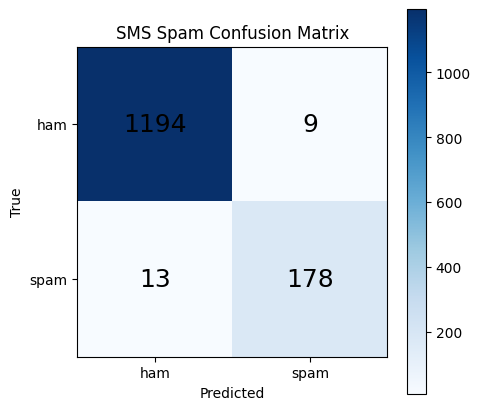

In [27]:
cm = confusion_matrix(y_test, y_pred, labels=["ham", "spam"])

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap="Blues")

plt.xticks([0, 1], ["ham", "spam"])
plt.yticks([0, 1], ["ham", "spam"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=18)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("SMS Spam Confusion Matrix")

plt.colorbar()
plt.show()

#### Error Analysis

In [28]:
results = pd.DataFrame({
    "message": X_test_text,
    "true": y_test,
    "predicted": y_pred
})

mistakes = results[results["true"] != results["predicted"]]

mistakes.head(10)

,message,true,predicted
3742,2/2 146tf150p,spam,ham
4600,Have you laid your airtel line to rest?,ham,spam
1893,CALL 09090900040 & LISTEN TO EXTREME DIRTY LIV...,spam,ham
4419,"When you get free, call me",ham,spam
2663,Hello darling how are you today? I would love ...,spam,ham
4821,Check Out Choose Your Babe Videos @ sms.shsex....,spam,ham
751,"Do you realize that in about 40 years, we'll h...",spam,ham
4702,I liked the new mobile,ham,spam
3864,Oh my god! I've found your number again! I'm s...,spam,ham
5046,We have sent JD for Customer Service cum Accou...,ham,spam


### Questions

1. What kinds of messages are misclassified? There are two primary categories of incorrectly classified messages: spam messages that are very short or do not contain common spam-related keywords, and normal (ham) messages that include casual or informal language frequently associated with spam.
2. Are false positives or false negatives more problematic here? We have false Positives, where legitimate messages are incorrectly marked as spam, are much more serious and problematic.
3. Which words seem to influence the model? Frequently occurring action-related words such as “call,” “text,” “free,” and “win,” along with financial or adult-related terms like “videos,” heavily influence the model’s predictions.
4. Does removing stopwords help? Yes, it provides a significant improvement.
5. Would a human make the same mistakes? No, because humans understand context, meaning, and intention, while a Naive Bayes model only analyzes sentences as collections of independent word frequencies without understanding their actual meaning.

## Extra Exercise — Use TF-IDF Instead of Word Counts

Until now, we used `CountVectorizer`, which counts how many times each word appears.

Now try using TF-IDF with `TfidfVectorizer` instead. Docs [here](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html).

**Task:**

Replace this code:

```python
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TODO: import the TF-IDF vectorizer

# TODO: create the vectorizer

# TODO: fit on the training text and transform it

# TODO: transform the test text

In [29]:
# TODO: import the TF-IDF vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# TODO: create the vectorizer
vectorizer = TfidfVectorizer(stop_words="english")

# TODO: fit on the training text and transform it
X_train = vectorizer.fit_transform(X_train_text)

# TODO: transform the test text
X_test = vectorizer.transform(X_test_text)

### To remember

* Bayes classification uses probabilities to choose the most likely class.
* Naive Bayes assumes words/features are independent given the class.
* Text must be converted into numbers before machine learning.
* Naive Bayes is **simple, fast, and often strong** for text classification.